# 0. An overview of force-indentation

In [1]:
%run _common.ipynb
%matplotlib inline

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from neuralconstitutive.indentation import (
    Constant,
    ConstantVelocity,
    IndentationBuilder,
)
from neuralconstitutive.tipgeometry import Spherical
from neuralconstitutive.constitutive import Hertzian, PowerLaw
from neuralconstitutive.ting.numerical import force_ting

A force-indentation experiment consists of three components:
 - Tip and sample geometry
 - Motion of the tip as it is pressed into then pulled out from the sample
 - Mechanical property of the sample

We first start with the tip/sample geometry.

The submodule `neuralconstitutive.tipgeometry` provides commonly used shapes such as `Spherical` and `Conical`.

By default, the sample is assumed to be infinitely thick.

In [2]:
# Create a tip with radius = 1.0, assuming infinitely thick sample
tip = Spherical(r=1.0)

Next is the motion of the tip, which we refer to as "indentation"
An indentation is composed of smaller segments, corresponding to one of approach / hold / retract phases.

Since hold and retract phases are optional and the segments must be ordered as approach -> hold -> retract,
this results in four types of indentation:
- Approach
- ApproachHold
- ApproachRetract
- ApproachHoldRetract

Below, we create an indentation with all three phases present using the `IndentationBuilder` class for convenience.

Text(0.5, 0, 'Time $t$')

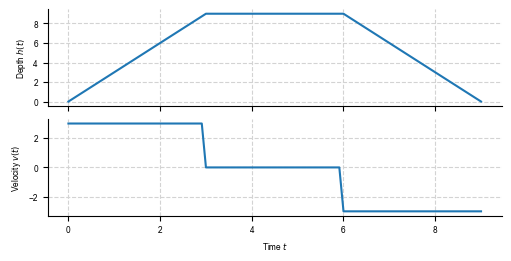

In [3]:
# Create a constant velocity approach-hold-retract indentation using the IndentationBuilder class
indentation = (
    IndentationBuilder()
    .append(ConstantVelocity(velocity_=3.0), duration=3.0)
    .append(Constant(), duration=3.0)
    .append(ConstantVelocity(velocity_=-3.0), duration=3.0)
    .build()
)

# Calculate the depth $h(t)$ and velocity $v(t)$ of the indenter as a function of time
t = jnp.linspace(0.0, 9.0, 100)
h_t = jax.vmap(indentation.depth)(t)
v_t = jax.vmap(indentation.velocity)(t)

# Inspect the resulting indentation
fig, axes = plt.subplots(2, 1, figsize = (5, 2.5), sharex = True)
ylabels = ("Depth $h(t)$", "Velocity $v(t)$")
for ax, y, ylabel in zip(axes, (h_t, v_t), ylabels):
    ax.plot(t, y)
    ax.set_ylabel(ylabel)
axes[1].set_xlabel("Time $t$")

Finally, we define the mechanical property of the sample.

We will compare two different viscoelastic constitutive models:
- Hertzian, which corresponds to a purely elastic sample
- Power law, which is an interpolation between pure viscous and pure elastic behavior.
    This model is usually used to describe the mechnical properties of cells.

We provide many different constitutive models in the submodule `neuralconstitutive.constitutive`.

The behaviors of different constitutive models can be checked by inspecting their (stress) relaxation functions $G(t)$, which is the response of the material when subjected to a unit step function strain in time.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


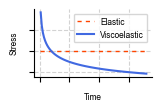

In [14]:
# Define two different constitutive models
hertzian = Hertzian(E0=3.0)
powerlaw = PowerLaw(E0=3.0, alpha=0.2)

# Compute relaxation functions
t = jnp.linspace(0.0, 9.0, 100)
G_hertzian = hertzian.relaxation_function(t)
G_powerlaw = powerlaw.relaxation_function(t)

# Inspect the resulting relaxation functions
fig, ax = plt.subplots(1, 1, figsize = (1.5, 1.0))
ax.plot(t, G_hertzian, color = "orangered", linewidth = 1.0, dashes = (3, 3), label = "Elastic")
ax.plot(t, G_powerlaw, color = "royalblue", label = "Viscoelastic")
ax.set_xlabel("Time")
ax.set_ylabel("Stress")
ax.legend(fontsize = "medium")
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
fig.savefig("../figures/fig1-a.eps", format = "eps", dpi=1200)

In [7]:
f_hertzian = force_ting(t, hertzian, indentation, tip)
f_powerlaw = force_ting(t, powerlaw, indentation, tip)


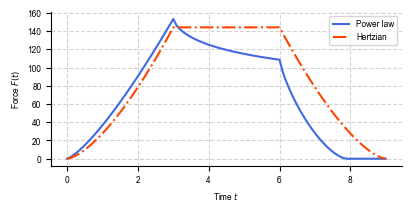

In [8]:
fig, ax = plt.subplots(1, 1, figsize = (4, 2))

ax.plot(t, f_powerlaw, "-", color = "royalblue", label = "Power law")
ax.plot(t, f_hertzian, "-.", color = "orangered", label = "Hertzian")
ax.set_xlabel("Time $t$")
ax.set_ylabel("Force $F(t)$")
ax.legend(loc = "upper right")

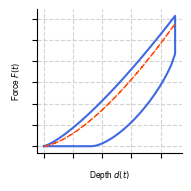

In [9]:
fig, ax = plt.subplots(1, 1, figsize = (1.8, 1.8))
ax.plot(h_t, f_powerlaw, "-", color = "royalblue", label = "Power law")
ax.plot(h_t, f_hertzian, "-.", color = "orangered", linewidth = 1.0, dashes = (3, 3), label = "Hertzian")
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.set_xlabel("Depth $d(t)$")
ax.set_ylabel("Force $F(t)$")
#ax.legend(loc = "upper left")
fig.savefig("../figures/fig1-c.eps", format = "eps", dpi=1200)

Putting it altogether, we have:

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


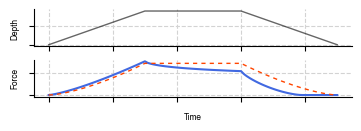

In [10]:
fig, axes = plt.subplots(2, 1, figsize = (3.5, 1.2), sharex = True)
axes[0].plot(t, h_t, color = "black", linewidth = 1.0, alpha = 0.6)
axes[0].set_ylabel("Depth")

axes[1].plot(t, f_powerlaw, "-", color = "royalblue", label = "Power law")
axes[1].plot(t, f_hertzian, "--", color = "orangered", linewidth = 1.0, dashes = (3, 3), label = "Hertzian")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Force")
#axes[1].legend(loc = "upper right")

for ax in axes:
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])

fig.savefig("../figures/fig1-b.eps", format = "eps", dpi=1200)